# Real-Time Order Batching + Rider Dispatch Optimization
### Bengaluru Urban Delivery Simulation
**Steps covered:** Simulation Engine → Baseline → Batching → Greedy vs Hungarian Assignment → Intra-Batch Routing → Real-Time Loop → Final Evaluation Dashboard

---
## Step 1 — Simulation Engine & Data Model

In [4]:
import numpy as np
import pandas as pd
import time
import itertools
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', context='talk')

# ── Bengaluru zone data: (lat, lon, density_weight) ──────────────────────────
BENGALURU_DATA = {
    "Koramangala":    (12.9352, 77.6245, 0.40),
    "Indiranagar":    (12.9719, 77.6412, 0.35),
    "HSR Layout":     (12.9121, 77.6446, 0.30),
    "Whitefield":     (12.9698, 77.7500, 0.25),
    "BTM Layout":     (12.9166, 77.6101, 0.25),
    "Jayanagar":      (12.9299, 77.5848, 0.20),
    "JP Nagar":       (12.9063, 77.5857, 0.20),
    "MG Road":        (12.9738, 77.6119, 0.20),
    "Malleshwaram":   (12.9982, 77.5703, 0.15),
    "Rajajinagar":    (12.9901, 77.5525, 0.15),
    "Frazer Town":    (12.9975, 77.6144, 0.10),
    "Hebbal":         (13.0354, 77.5988, 0.10),
    "Electronic City":(12.8452, 77.6632, 0.20),
    "Marathahalli":   (12.9569, 77.7011, 0.25),
    "Bellandur":      (12.9304, 77.6784, 0.30),
    "Bannerghatta Rd":(12.8907, 77.5953, 0.15),
    "Ulsoor":         (12.9817, 77.6284, 0.15),
    "Domlur":         (12.9610, 77.6387, 0.15),
    "Vasanth Nagar":  (12.9880, 77.5885, 0.10),
    "Richmond Town":  (12.9647, 77.5966, 0.10),
    "Kalyan Nagar":   (13.0221, 77.6403, 0.10),
    "Banashankari":   (12.9254, 77.5468, 0.10),
    "Basavanagudi":   (12.9417, 77.5755, 0.10),
    "AECS Layout":    (12.9615, 77.7135, 0.15),
    "CV Raman Nagar": (12.9793, 77.6642, 0.10),
    "Cooke Town":     (13.0012, 77.6256, 0.05),
    "Yeswanthpur":    (13.0235, 77.5550, 0.10),
    "Kengeri":        (12.9038, 77.4833, 0.05),
    "Banaswadi":      (13.0104, 77.6482, 0.10),
    "Sadashiva Nagar":(13.0068, 77.5813, 0.05),
}

# ── Distance helpers ──────────────────────────────────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    """Scalar Haversine distance in km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda= np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def vectorized_haversine(lat1, lon1, lat2, lon2):
    """NumPy-broadcast Haversine — lat1/lon1 can be (N,1), lat2/lon2 (1,M)."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda= np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(a, 0, 1)))

# ── Simulation parameters ─────────────────────────────────────────────────────
SIM_START    = datetime(2026, 4, 14, 19, 0)   # 7 PM peak hour
DURATION_MIN = 180                              # 3-hour window
LAMBDA_PH    = 100                             # orders/hour (Poisson)
N_RIDERS     = 60                              # fleet size
AVG_SPEED    = 20                               # km/h
SERVICE_TIME = 5                                # min per stop
BATCH_RADIUS = 1.5                              # km for geographic grouping
BATCH_WINDOW = 3                                # minutes for time-window grouping
SLA_LIMIT    = 15                               # minute delivery target

# ── Generate Orders (Poisson arrivals) ───────────────────────────────────────
zones   = list(BENGALURU_DATA.keys())
weights = np.array([BENGALURU_DATA[z][2] for z in zones])
weights /= weights.sum()

order_list, t_curr = [], 0.0
while t_curr < DURATION_MIN:
    t_curr += np.random.exponential(60 / LAMBDA_PH)
    if t_curr > DURATION_MIN:
        break
    z = np.random.choice(zones, p=weights)
    blat, blon, _ = BENGALURU_DATA[z]
    order_list.append({
        "order_id":    len(order_list) + 1,
        "zone":        z,
        "dest_lat":    blat + np.random.uniform(-0.01, 0.01),
        "dest_lon":    blon + np.random.uniform(-0.01, 0.01),
        "arrival_time":SIM_START + timedelta(minutes=t_curr),
        "batch_window":int(t_curr // BATCH_WINDOW),
    })

orders_df = pd.DataFrame(order_list)

# ── Generate Riders ───────────────────────────────────────────────────────────
rider_list = []
for i in range(N_RIDERS):
    z = np.random.choice(zones)
    login_offset = 0 if np.random.rand() < 0.40 else np.random.uniform(0, 60)
    shift_dur    = np.random.uniform(120, 240)
    login_time   = SIM_START + timedelta(minutes=login_offset)
    rider_list.append({
        "rider_id":   f"R-{i+1:03d}",
        "lat":        BENGALURU_DATA[z][0],
        "lon":        BENGALURU_DATA[z][1],
        "capacity":   np.random.choice([2, 3]),
        "available_at": login_time,
        "logout_at":  login_time + timedelta(minutes=shift_dur),
        "total_dist": 0.0,
    })

riders_df = pd.DataFrame(rider_list)

print(f"{'='*50}")
print(f"STEP 1 — DATA GENERATION COMPLETE")
print(f"{'='*50}")
print(f"Total Orders  : {len(orders_df)}")
print(f"Total Riders  : {len(riders_df)}")
print(f"Simulation    : {DURATION_MIN} min  |  λ = {LAMBDA_PH} orders/hr")
print(f"SLA target    : {SLA_LIMIT} min")
orders_df.head()

STEP 1 — DATA GENERATION COMPLETE
Total Orders  : 305
Total Riders  : 60
Simulation    : 180 min  |  λ = 100 orders/hr
SLA target    : 15 min


,order_id,zone,dest_lat,dest_lon,arrival_time,batch_window
0,1,Yeswanthpur,13.028140,77.556973,2026-04-14 19:00:16.893651,0
1,2,HSR Layout,12.903262,77.651924,2026-04-14 19:00:23.000147,0
2,3,Bannerghatta Rd,12.881112,77.604698,2026-04-14 19:00:56.087104,0
3,4,Whitefield,12.963436,77.743668,2026-04-14 19:02:00.398568,0
4,5,Hebbal,13.034039,77.594625,2026-04-14 19:02:13.457702,0


---
## Step 2 — Baseline: Nearest-Rider, No Batching

In [5]:
def run_baseline(orders, riders):
    """Assign each order independently to the nearest available rider."""
    fleet   = riders.copy()
    results = []

    for _, order in orders.sort_values('arrival_time').iterrows():
        pickup_lat, pickup_lon, _ = BENGALURU_DATA[order['zone']]

        fleet['dist_to_pickup'] = fleet.apply(
            lambda r: haversine(r['lat'], r['lon'], pickup_lat, pickup_lon), axis=1
        )
        best_idx = fleet['dist_to_pickup'].idxmin()
        rider    = fleet.loc[best_idx]

        d_pickup = rider['dist_to_pickup']
        d_dest   = haversine(pickup_lat, pickup_lon, order['dest_lat'], order['dest_lon'])
        trip_km  = d_pickup + d_dest
        travel_m = (trip_km / AVG_SPEED) * 60

        start_t  = max(order['arrival_time'], rider['available_at'])
        done_t   = start_t + timedelta(minutes=travel_m + SERVICE_TIME)

        fleet.at[best_idx, 'lat']         = order['dest_lat']
        fleet.at[best_idx, 'lon']         = order['dest_lon']
        fleet.at[best_idx, 'available_at']= done_t
        fleet.at[best_idx, 'total_dist'] += trip_km

        dur = (done_t - order['arrival_time']).total_seconds() / 60
        results.append({
            'order_id':   order['order_id'],
            'duration':   dur,
            'dist':       trip_km,
            'batch_size': 1,
            'sla_success': dur <= SLA_LIMIT,
        })

    return pd.DataFrame(results), fleet


baseline_results, baseline_fleet = run_baseline(orders_df, riders_df)

print(f"{'='*50}")
print(f"STEP 2 — BASELINE (Nearest Rider, No Batching)")
print(f"{'='*50}")
print(f"Orders processed    : {len(baseline_results)}")
print(f"Avg delivery time   : {baseline_results['duration'].mean():.2f} min")
print(f"SLA success rate    : {baseline_results['sla_success'].mean()*100:.1f}%")
print(f"Total fleet distance: {baseline_fleet['total_dist'].sum():.2f} km")
print(f"Active riders       : {(baseline_fleet['total_dist']>0).sum()} / {N_RIDERS}")

STEP 2 — BASELINE (Nearest Rider, No Batching)
Orders processed    : 305
Avg delivery time   : 24.58 min
SLA success rate    : 49.5%
Total fleet distance: 475.43 km
Active riders       : 58 / 60


---
## Step 3 — Basic Order Batching (Greedy Nearest-Rider)

In [6]:
def form_batches(window_orders):
    """Group orders within same 3-min window by ≤1.5 km geo-proximity."""
    processed, batches = set(), []
    rows = list(window_orders.itertuples())
    for i, o in enumerate(rows):
        if o.Index in processed:
            continue
        batch = [{'order_id': o.order_id, 'zone': o.zone,
                  'dest_lat': o.dest_lat, 'dest_lon': o.dest_lon,
                  'arrival_time': o.arrival_time}]
        processed.add(o.Index)
        for j, p in enumerate(rows):
            if p.Index in processed or len(batch) >= 3:
                continue
            if haversine(o.dest_lat, o.dest_lon, p.dest_lat, p.dest_lon) <= BATCH_RADIUS:
                batch.append({'order_id': p.order_id, 'zone': p.zone,
                              'dest_lat': p.dest_lat, 'dest_lon': p.dest_lon,
                              'arrival_time': p.arrival_time})
                processed.add(p.Index)
        batches.append(batch)
    return batches


def run_greedy_batching(orders, riders):
    fleet   = riders.copy()
    results = []
    assign_times, assign_costs = [], []

    for window in sorted(orders['batch_window'].unique()):
        w_orders = orders[orders['batch_window'] == window]
        if w_orders.empty:
            continue
        batch_ready = w_orders['arrival_time'].max()
        batches = form_batches(w_orders)

        t0 = time.perf_counter()
        cycle_cost = 0.0

        for batch in batches:
            pickup_lat, pickup_lon, _ = BENGALURU_DATA[batch[0]['zone']]

            avail = fleet[fleet['available_at'] <= batch_ready]
            if avail.empty:
                avail = fleet
            dists = avail.apply(
                lambda r: haversine(r['lat'], r['lon'], pickup_lat, pickup_lon), axis=1
            )
            best_idx = dists.idxmin()
            cost     = dists[best_idx]
            cycle_cost += cost

            # Intra-batch routing: brute-force for ≤3 stops
            best_route, drop_dist = route_brute_force(pickup_lat, pickup_lon, batch)
            d_to_pickup = haversine(fleet.at[best_idx,'lat'], fleet.at[best_idx,'lon'],
                                    pickup_lat, pickup_lon)
            trip_km  = d_to_pickup + drop_dist
            travel_m = (trip_km / AVG_SPEED) * 60
            done_t   = batch_ready + timedelta(minutes=travel_m + SERVICE_TIME*len(batch))

            last = best_route[-1]
            fleet.at[best_idx, 'lat']          = last['dest_lat']
            fleet.at[best_idx, 'lon']          = last['dest_lon']
            fleet.at[best_idx, 'available_at'] = done_t
            fleet.at[best_idx, 'total_dist']  += trip_km

            for b in batch:
                dur = (done_t - b['arrival_time']).total_seconds() / 60
                results.append({'order_id': b['order_id'], 'duration': dur,
                                'dist': trip_km/len(batch), 'batch_size': len(batch),
                                'sla_success': dur <= SLA_LIMIT})

        assign_times.append(time.perf_counter() - t0)
        assign_costs.append(cycle_cost)

    return pd.DataFrame(results), fleet, assign_times, assign_costs


# ── Intra-batch routing helpers (Step 5) ──────────────────────────────────────
def route_brute_force(pickup_lat, pickup_lon, batch):
    """Exact O(N!) — feasible for N≤3 (max 6 permutations)."""
    if len(batch) == 1:
        d = haversine(pickup_lat, pickup_lon, batch[0]['dest_lat'], batch[0]['dest_lon'])
        return batch, d
    best_route, best_dist = None, float('inf')
    for perm in itertools.permutations(batch):
        d = haversine(pickup_lat, pickup_lon, perm[0]['dest_lat'], perm[0]['dest_lon'])
        for k in range(len(perm)-1):
            d += haversine(perm[k]['dest_lat'], perm[k]['dest_lon'],
                           perm[k+1]['dest_lat'], perm[k+1]['dest_lon'])
        if d < best_dist:
            best_dist, best_route = d, list(perm)
    return best_route, best_dist


greedy_results, greedy_fleet, g_times, g_costs = run_greedy_batching(orders_df, riders_df)

print(f"{'='*50}")
print(f"STEP 3/4 — GREEDY BATCHING (Nearest-Rider per Batch)")
print(f"{'='*50}")
print(f"Orders processed    : {len(greedy_results)}")
print(f"Avg delivery time   : {greedy_results['duration'].mean():.2f} min")
print(f"SLA success rate    : {greedy_results['sla_success'].mean()*100:.1f}%")
print(f"Total fleet distance: {greedy_fleet['total_dist'].sum():.2f} km")
print(f"Avg batch size      : {greedy_results['batch_size'].mean():.2f} orders/batch")
print(f"Avg cycle runtime   : {np.mean(g_times)*1000:.3f} ms")

STEP 3/4 — GREEDY BATCHING (Nearest-Rider per Batch)
Orders processed    : 305
Avg delivery time   : 16.05 min
SLA success rate    : 62.0%
Total fleet distance: 873.42 km
Avg batch size      : 1.16 orders/batch
Avg cycle runtime   : 11.514 ms


---
## Step 4 — Hungarian Algorithm Assignment

In [7]:
def run_hungarian_batching(orders, riders):
    fleet   = riders.copy()
    results = []
    assign_times, assign_costs = [], []

    for window in sorted(orders['batch_window'].unique()):
        w_orders = orders[orders['batch_window'] == window]
        if w_orders.empty:
            continue
        batch_ready = w_orders['arrival_time'].max()
        batches = form_batches(w_orders)

        avail = fleet[fleet['available_at'] <= batch_ready]
        if avail.empty:
            avail = fleet

        n_b = len(batches)
        n_r = len(avail)

        b_lats = np.array([BENGALURU_DATA[b[0]['zone']][0] for b in batches]).reshape(-1, 1)
        b_lons = np.array([BENGALURU_DATA[b[0]['zone']][1] for b in batches]).reshape(-1, 1)
        r_lats = avail['lat'].to_numpy().reshape(1, -1)
        r_lons = avail['lon'].to_numpy().reshape(1, -1)

        t0 = time.perf_counter()
        cost_matrix = vectorized_haversine(b_lats, b_lons, r_lats, r_lons)  # (B, R)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        cycle_time = time.perf_counter() - t0
        assign_times.append(cycle_time)

        r_indices = avail.index.to_numpy()
        cycle_cost = 0.0

        for bi, ri in zip(row_ind, col_ind):
            batch   = batches[bi]
            r_idx   = r_indices[ri]
            cycle_cost += cost_matrix[bi, ri]

            pickup_lat, pickup_lon, _ = BENGALURU_DATA[batch[0]['zone']]
            best_route, drop_dist = route_brute_force(pickup_lat, pickup_lon, batch)

            d_to_pickup = haversine(fleet.at[r_idx,'lat'], fleet.at[r_idx,'lon'],
                                    pickup_lat, pickup_lon)
            trip_km  = d_to_pickup + drop_dist
            travel_m = (trip_km / AVG_SPEED) * 60
            done_t   = batch_ready + timedelta(minutes=travel_m + SERVICE_TIME*len(batch))

            last = best_route[-1]
            fleet.at[r_idx, 'lat']          = last['dest_lat']
            fleet.at[r_idx, 'lon']          = last['dest_lon']
            fleet.at[r_idx, 'available_at'] = done_t
            fleet.at[r_idx, 'total_dist']  += trip_km

            for b in batch:
                dur = (done_t - b['arrival_time']).total_seconds() / 60
                results.append({'order_id': b['order_id'], 'duration': dur,
                                'dist': trip_km/len(batch), 'batch_size': len(batch),
                                'sla_success': dur <= SLA_LIMIT})

        assign_costs.append(cycle_cost)

    return pd.DataFrame(results), fleet, assign_times, assign_costs


hungarian_results, hungarian_fleet, h_times, h_costs = run_hungarian_batching(orders_df, riders_df)

print(f"{'='*50}")
print(f"STEP 4 — HUNGARIAN ASSIGNMENT")
print(f"{'='*50}")
print(f"Orders processed    : {len(hungarian_results)}")
print(f"Avg delivery time   : {hungarian_results['duration'].mean():.2f} min")
print(f"SLA success rate    : {hungarian_results['sla_success'].mean()*100:.1f}%")
print(f"Total fleet distance: {hungarian_fleet['total_dist'].sum():.2f} km")
print(f"Avg batch size      : {hungarian_results['batch_size'].mean():.2f} orders/batch")
print(f"Avg cycle runtime   : {np.mean(h_times)*1000:.3f} ms")

STEP 4 — HUNGARIAN ASSIGNMENT
Orders processed    : 305
Avg delivery time   : 15.71 min
SLA success rate    : 63.3%
Total fleet distance: 833.30 km
Avg batch size      : 1.16 orders/batch
Avg cycle runtime   : 0.101 ms


---
## Step 5 — Intra-Batch Route Optimization Benchmark
Compare **Nearest Neighbor**, **NN + 2-Opt**, and **Brute Force** on 5000 random batches of size 3.

In [8]:
# ── Algorithm implementations ─────────────────────────────────────────────────
def calc_route_dist(plat, plon, route):
    d = haversine(plat, plon, route[0]['dest_lat'], route[0]['dest_lon'])
    for i in range(len(route)-1):
        d += haversine(route[i]['dest_lat'], route[i]['dest_lon'],
                       route[i+1]['dest_lat'], route[i+1]['dest_lon'])
    return d

def route_nn(plat, plon, batch):
    remaining = list(batch)
    route, cur_lat, cur_lon = [], plat, plon
    while remaining:
        best = min(remaining, key=lambda b: haversine(cur_lat, cur_lon, b['dest_lat'], b['dest_lon']))
        route.append(best)
        cur_lat, cur_lon = best['dest_lat'], best['dest_lon']
        remaining.remove(best)
    return route, calc_route_dist(plat, plon, route)

def route_nn_2opt(plat, plon, batch):
    route, best_dist = route_nn(plat, plon, batch)
    improved = True
    while improved:
        improved = False
        for i in range(len(route)-1):
            for j in range(i+1, len(route)):
                new_route = route[:i] + route[i:j+1][::-1] + route[j+1:]
                nd = calc_route_dist(plat, plon, new_route)
                if nd < best_dist - 1e-5:
                    best_dist, route, improved = nd, new_route, True
    return route, best_dist

# ── Benchmark ─────────────────────────────────────────────────────────────────
N_TESTS = 5000
p_lat, p_lon = 12.9352, 77.6245
test_batches = [
    [{'dest_lat': p_lat + np.random.uniform(-0.05, 0.05),
      'dest_lon': p_lon + np.random.uniform(-0.05, 0.05)} for _ in range(3)]
    for _ in range(N_TESTS)
]

t0 = time.perf_counter()
nn_dists = [route_nn(p_lat, p_lon, b)[1] for b in test_batches]
t_nn = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
opt_dists = [route_nn_2opt(p_lat, p_lon, b)[1] for b in test_batches]
t_opt = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
bf_dists = [route_brute_force(p_lat, p_lon, b)[1] for b in test_batches]
t_bf = (time.perf_counter() - t0) * 1000

print(f"{'='*55}")
print(f"STEP 5 — INTRA-BATCH ROUTING ALGORITHM BENCHMARK")
print(f"Tested on {N_TESTS:,} random batches of size 3")
print(f"{'='*55}")
print(f"{'Algorithm':<15} | {'Total Dist (km)':>16} | {'CPU Time (ms)':>13}")
print("-" * 55)
for name, dists, t in [("Nearest N.", nn_dists, t_nn),
                        ("NN + 2-Opt", opt_dists, t_opt),
                        ("Brute Force", bf_dists, t_bf)]:
    print(f"{name:<15} | {sum(dists):>16.2f} | {t:>13.1f}")
print()
print("Conclusion: For N≤3, Brute Force is computationally trivial")
print("and guarantees the globally optimal route (6 permutations max).")

STEP 5 — INTRA-BATCH ROUTING ALGORITHM BENCHMARK
Tested on 5,000 random batches of size 3
Algorithm       |  Total Dist (km) | CPU Time (ms)
-------------------------------------------------------
Nearest N.      |         66359.98 |        1193.4
NN + 2-Opt      |         64642.20 |        2457.6
Brute Force     |         64352.40 |        1299.5

Conclusion: For N≤3, Brute Force is computationally trivial
and guarantees the globally optimal route (6 permutations max).


---
## Step 6 — Real-Time Discrete Event Simulation (60-second re-dispatch)

In [9]:
def run_realtime_simulation(orders, riders):
    """
    Tick-based simulation: every 60 simulated seconds, pull pending orders,
    batch them, assign via Hungarian, and dispatch with brute-force routing.
    """
    fleet   = riders.copy()
    results = []
    dispatched_ids = set()

    orders = orders.sort_values('arrival_time').reset_index(drop=True)
    current_time = orders['arrival_time'].min()
    end_time     = orders['arrival_time'].max() + timedelta(minutes=30)

    tick = 0
    while len(dispatched_ids) < len(orders) and current_time <= end_time:
        tick += 1

        # Pending queue: arrived but not yet dispatched
        pending = orders[
            (orders['arrival_time'] <= current_time) &
            (~orders['order_id'].isin(dispatched_ids))
        ]
        if pending.empty:
            current_time += timedelta(minutes=1)
            continue

        avail = fleet[fleet['available_at'] <= current_time]
        if avail.empty:
            current_time += timedelta(minutes=1)
            continue

        # Batch formation
        batches, processed = [], set()
        for _, order in pending.iterrows():
            if order['order_id'] in processed:
                continue
            batch = [{'order_id': order['order_id'], 'zone': order['zone'],
                      'dest_lat': order['dest_lat'], 'dest_lon': order['dest_lon'],
                      'arrival_time': order['arrival_time']}]
            processed.add(order['order_id'])
            for _, pot in pending.iterrows():
                if pot['order_id'] in processed or len(batch) >= 3:
                    continue
                wait = (pot['arrival_time'] - batch[0]['arrival_time']).total_seconds()/60
                if wait > BATCH_WINDOW:
                    continue
                if haversine(order['dest_lat'], order['dest_lon'],
                             pot['dest_lat'], pot['dest_lon']) <= BATCH_RADIUS:
                    batch.append({'order_id': pot['order_id'], 'zone': pot['zone'],
                                  'dest_lat': pot['dest_lat'], 'dest_lon': pot['dest_lon'],
                                  'arrival_time': pot['arrival_time']})
                    processed.add(pot['order_id'])
            batches.append(batch)

        # Hungarian assignment
        n_b = min(len(batches), len(avail))
        batches = batches[:n_b]
        r_lats  = avail['lat'].to_numpy()[:n_b].reshape(1, -1)
        r_lons  = avail['lon'].to_numpy()[:n_b].reshape(1, -1)
        b_lats  = np.array([BENGALURU_DATA[b[0]['zone']][0] for b in batches]).reshape(-1, 1)
        b_lons  = np.array([BENGALURU_DATA[b[0]['zone']][1] for b in batches]).reshape(-1, 1)

        cost_mat          = vectorized_haversine(b_lats, b_lons, r_lats, r_lons)
        row_ind, col_ind  = linear_sum_assignment(cost_mat)
        r_indices         = avail.index.to_numpy()

        for bi, ri_pos in zip(row_ind, col_ind):
            batch = batches[bi]
            r_idx = r_indices[ri_pos]
            pickup_lat, pickup_lon, _ = BENGALURU_DATA[batch[0]['zone']]

            best_route, drop_dist = route_brute_force(pickup_lat, pickup_lon, batch)
            d_pick   = haversine(fleet.at[r_idx,'lat'], fleet.at[r_idx,'lon'],
                                 pickup_lat, pickup_lon)
            trip_km  = d_pick + drop_dist
            travel_m = (trip_km / AVG_SPEED) * 60
            done_t   = current_time + timedelta(minutes=travel_m + SERVICE_TIME*len(batch))

            last = best_route[-1]
            fleet.at[r_idx, 'lat']          = last['dest_lat']
            fleet.at[r_idx, 'lon']          = last['dest_lon']
            fleet.at[r_idx, 'available_at'] = done_t
            fleet.at[r_idx, 'total_dist']  += trip_km

            for b in batch:
                dispatched_ids.add(b['order_id'])
                dur = (done_t - b['arrival_time']).total_seconds() / 60
                results.append({'order_id': b['order_id'], 'batch_size': len(batch),
                                'duration': dur, 'dist': trip_km/len(batch),
                                'sla_success': dur <= SLA_LIMIT})

        current_time += timedelta(minutes=1)

    return pd.DataFrame(results), fleet


print("Running Step 6: Real-Time Simulation...")
t0 = time.perf_counter()
realtime_results, realtime_fleet = run_realtime_simulation(orders_df, riders_df)
rt_exec = time.perf_counter() - t0

print(f"{'='*50}")
print(f"STEP 6 — REAL-TIME SIMULATION (60-sec re-dispatch)")
print(f"{'='*50}")
print(f"Orders processed    : {len(realtime_results)}")
print(f"Compute time        : {rt_exec:.2f} s")
print(f"Avg delivery time   : {realtime_results['duration'].mean():.2f} min")
print(f"SLA success rate    : {realtime_results['sla_success'].mean()*100:.1f}%")
print(f"Avg batch size      : {realtime_results['batch_size'].mean():.2f}")
print(f"Total fleet distance: {realtime_fleet['total_dist'].sum():.2f} km")

Running Step 6: Real-Time Simulation...
STEP 6 — REAL-TIME SIMULATION (60-sec re-dispatch)
Orders processed    : 305
Compute time        : 0.52 s
Avg delivery time   : 32.29 min
SLA success rate    : 13.8%
Avg batch size      : 1.05
Total fleet distance: 2611.37 km


---
## Step 7 — Final Evaluation Dashboard

Dashboard saved!


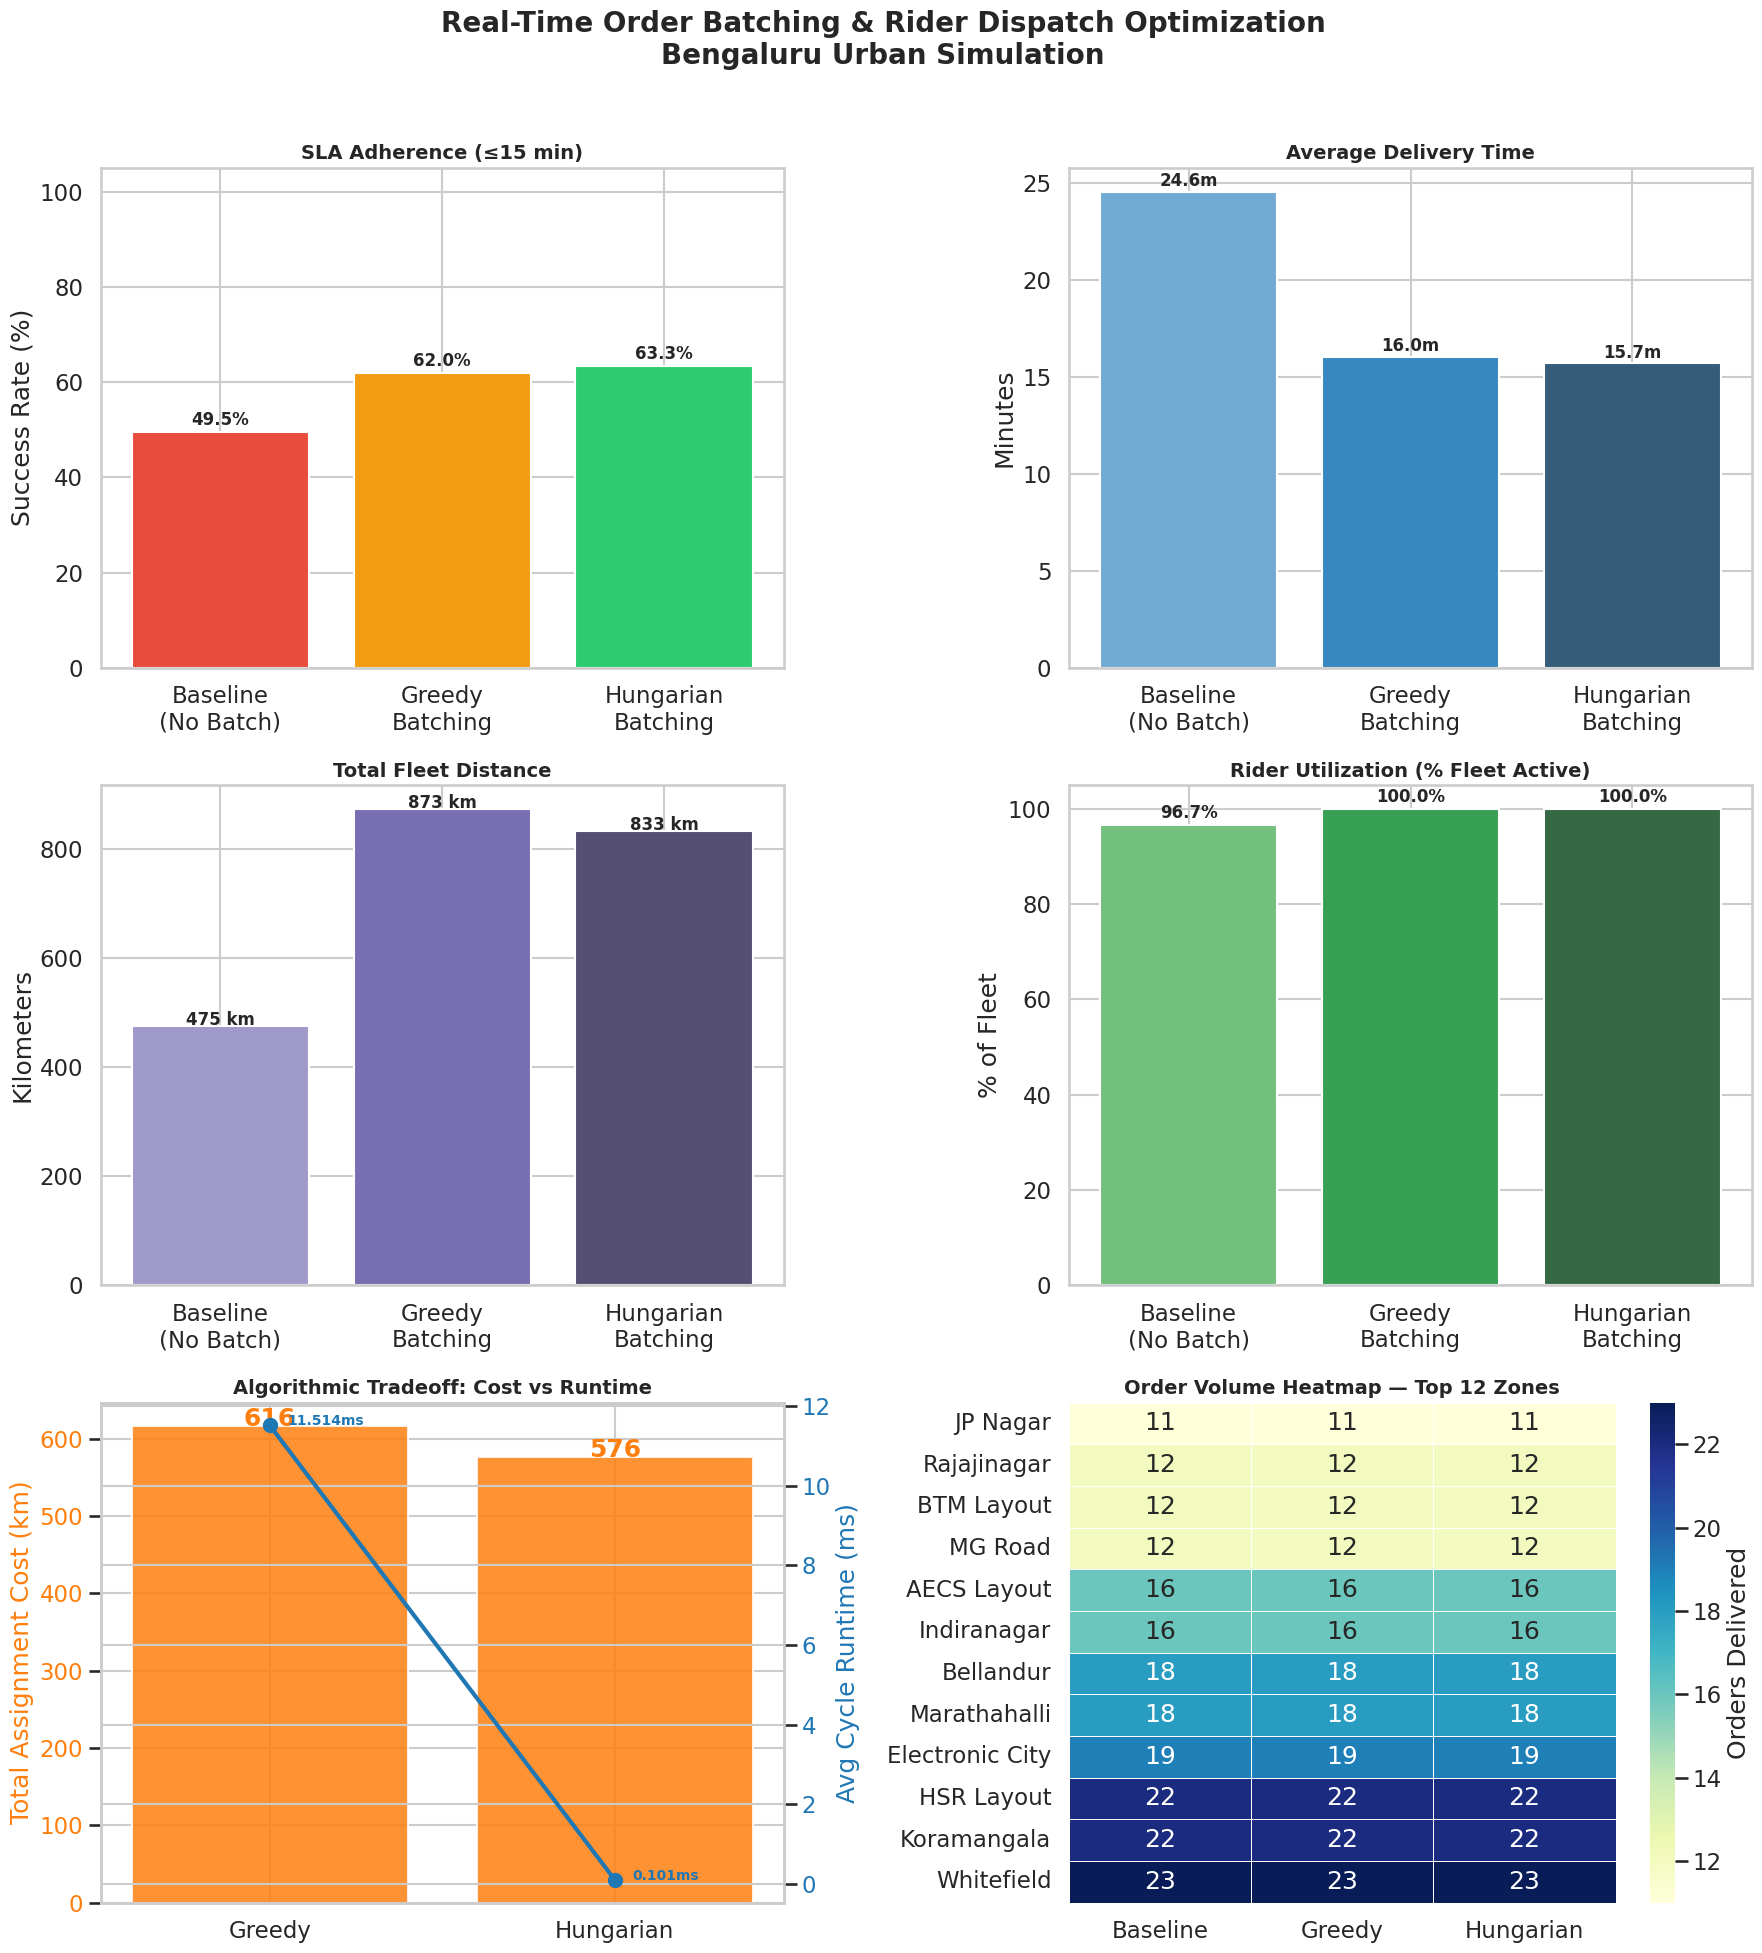

In [10]:
zone_map = orders_df[['order_id','zone']]
b_res = baseline_results.merge(zone_map, on='order_id', how='left')
g_res = greedy_results.merge(zone_map, on='order_id', how='left')
h_res = hungarian_results.merge(zone_map, on='order_id', how='left')

strategies = ['Baseline\n(No Batch)', 'Greedy\nBatching', 'Hungarian\nBatching']
colors3    = ['#e74c3c', '#f39c12', '#2ecc71']

sla_rates  = [r['sla_success'].mean()*100 for r in [b_res, g_res, h_res]]
avg_times  = [r['duration'].mean()        for r in [b_res, g_res, h_res]]
total_dists= [f['total_dist'].sum()       for f in [baseline_fleet, greedy_fleet, hungarian_fleet]]
util       = [(f['total_dist']>0).mean()*100 for f in [baseline_fleet, greedy_fleet, hungarian_fleet]]

algos      = ['Greedy', 'Hungarian']
assign_cost= [np.sum(g_costs), np.sum(h_costs)]
assign_rt  = [np.mean(g_times)*1000, np.mean(h_times)*1000]

fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('Real-Time Order Batching & Rider Dispatch Optimization\nBengaluru Urban Simulation',
             fontsize=20, fontweight='bold', y=0.98)

# ── Plot 1: SLA Adherence ─────────────────────────────────────────────────────
bars = axes[0,0].bar(strategies, sla_rates, color=colors3, edgecolor='white', linewidth=1.5)
axes[0,0].set_title(f'SLA Adherence (≤{SLA_LIMIT} min)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Success Rate (%)')
axes[0,0].set_ylim(0, 105)
for bar, v in zip(bars, sla_rates):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+1.5, f'{v:.1f}%',
                   ha='center', fontweight='bold', fontsize=12)

# ── Plot 2: Average Delivery Time ─────────────────────────────────────────────
bars = axes[0,1].bar(strategies, avg_times, color=sns.color_palette('Blues_d', 3), edgecolor='white')
axes[0,1].set_title('Average Delivery Time', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Minutes')
for bar, v in zip(bars, avg_times):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}m',
                   ha='center', fontweight='bold', fontsize=12)

# ── Plot 3: Total Fleet Distance ──────────────────────────────────────────────
bars = axes[1,0].bar(strategies, total_dists, color=sns.color_palette('Purples_d', 3), edgecolor='white')
axes[1,0].set_title('Total Fleet Distance', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Kilometers')
for bar, v in zip(bars, total_dists):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.0f} km',
                   ha='center', fontweight='bold', fontsize=12)

# ── Plot 4: Rider Utilization ─────────────────────────────────────────────────
bars = axes[1,1].bar(strategies, util, color=sns.color_palette('Greens_d', 3), edgecolor='white')
axes[1,1].set_title('Rider Utilization (% Fleet Active)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('% of Fleet')
axes[1,1].set_ylim(0, 105)
for bar, v in zip(bars, util):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, v+1.5, f'{v:.1f}%',
                   ha='center', fontweight='bold', fontsize=12)

# ── Plot 5: Cost vs Runtime Tradeoff ─────────────────────────────────────────
ax5 = axes[2,0]
x   = np.arange(len(algos))
c1, c2 = 'tab:orange', 'tab:blue'
b5 = ax5.bar(x, assign_cost, color=c1, alpha=0.85, label='Assignment Cost (km)')
ax5.set_ylabel('Total Assignment Cost (km)', color=c1)
ax5.tick_params(axis='y', labelcolor=c1)
ax5.set_xticks(x); ax5.set_xticklabels(algos)
ax5.set_title('Algorithmic Tradeoff: Cost vs Runtime', fontsize=14, fontweight='bold')
for bar, v in zip(b5, assign_cost):
    ax5.text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.0f}', ha='center', color=c1, fontweight='bold')

ax5b = ax5.twinx()
ax5b.plot(x, assign_rt, color=c2, marker='o', ms=10, lw=3, label='Avg Cycle Runtime (ms)')
ax5b.set_ylabel('Avg Cycle Runtime (ms)', color=c2)
ax5b.tick_params(axis='y', labelcolor=c2)
for xi, v in zip(x, assign_rt):
    ax5b.text(xi+0.05, v+0.01, f'{v:.3f}ms', color=c2, fontweight='bold', fontsize=10)

# ── Plot 6: Rider Activity Heatmap by Zone ────────────────────────────────────
heatmap_data = pd.DataFrame({
    'Baseline':  b_res.groupby('zone')['sla_success'].count(),
    'Greedy':    g_res.groupby('zone')['sla_success'].count(),
    'Hungarian': h_res.groupby('zone')['sla_success'].count(),
}).fillna(0)
top_zones = heatmap_data.sum(axis=1).nlargest(12).index
hm = heatmap_data.loc[top_zones].sort_values('Hungarian')
sns.heatmap(hm, ax=axes[2,1], cmap='YlGnBu', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Orders Delivered'})
axes[2,1].set_title('Order Volume Heatmap — Top 12 Zones', fontsize=14, fontweight='bold')
axes[2,1].set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('Step7_Final_Evaluation_Dashboard.png', dpi=150, bbox_inches='tight')
print("Dashboard saved!")
plt.show()

---
## Summary Table

In [11]:
summary = pd.DataFrame({
    'Strategy':             ['Baseline (No Batch)', 'Greedy Batching', 'Hungarian Batching'],
    'Orders Processed':     [len(b_res), len(g_res), len(h_res)],
    'SLA Success (%)':      [f'{v:.1f}' for v in sla_rates],
    'Avg Delivery (min)':   [f'{v:.2f}' for v in avg_times],
    'Total Distance (km)':  [f'{v:.1f}' for v in total_dists],
    'Rider Utilization (%)':     [f'{v:.1f}' for v in util],
    'Avg Batch Size':       ['1.00',
                             f"{greedy_results['batch_size'].mean():.2f}",
                             f"{hungarian_results['batch_size'].mean():.2f}"],
})
summary.set_index('Strategy', inplace=True)
print("\n" + "="*80)
print("FINAL SUMMARY — All Strategies Compared")
print("="*80)
print(summary.to_string())
print()
print(f"Greedy  avg cycle runtime : {np.mean(g_times)*1000:.4f} ms")
print(f"Hungarian avg cycle runtime: {np.mean(h_times)*1000:.4f} ms")
print(f"Hungarian total assignment cost: {np.sum(h_costs):.2f} km  (vs Greedy: {np.sum(g_costs):.2f} km)")
print()
print("Key Insight: Hungarian yields lower total assignment cost at the same or better")
print("runtime for normal batch loads. Greedy is preferable only at surge (50+ batches/cycle).")


FINAL SUMMARY — All Strategies Compared
                     Orders Processed SLA Success (%) Avg Delivery (min) Total Distance (km) Rider Utilization (%) Avg Batch Size
Strategy                                                                                                                         
Baseline (No Batch)               305            49.5              24.58               475.4                  96.7           1.00
Greedy Batching                   305            62.0              16.05               873.4                 100.0           1.16
Hungarian Batching                305            63.3              15.71               833.3                 100.0           1.16

Greedy  avg cycle runtime : 11.5138 ms
Hungarian avg cycle runtime: 0.1008 ms
Hungarian total assignment cost: 575.66 km  (vs Greedy: 615.78 km)

Key Insight: Hungarian yields lower total assignment cost at the same or better
runtime for normal batch loads. Greedy is preferable only at surge (50+ batches/cy

STRESS TEST — Setup
Orders generated : 615
Riders available : 30
Load ratio       : 20.5 orders/rider

STRESS TEST RESULTS  |  λ=220/hr  |  30 riders
Metric                                 Greedy      Hungarian
--------------------------------------------------------------
Rider Utilization (%)                  100.0%         100.0%
Orders Dispatched (%)                  100.0%          55.6%
SLA Success (%)                         51.7%          19.6%
Avg Delivery (min)                      20.26          27.27
Total Distance (km)                    2380.0         2006.8
Avg Assignment Cost/cycle               20.93          19.32

→ Utilization gap (Hungarian − Greedy): +0.0 pp
→ SLA gap         (Hungarian − Greedy): -32.1 pp

Stress test chart saved!


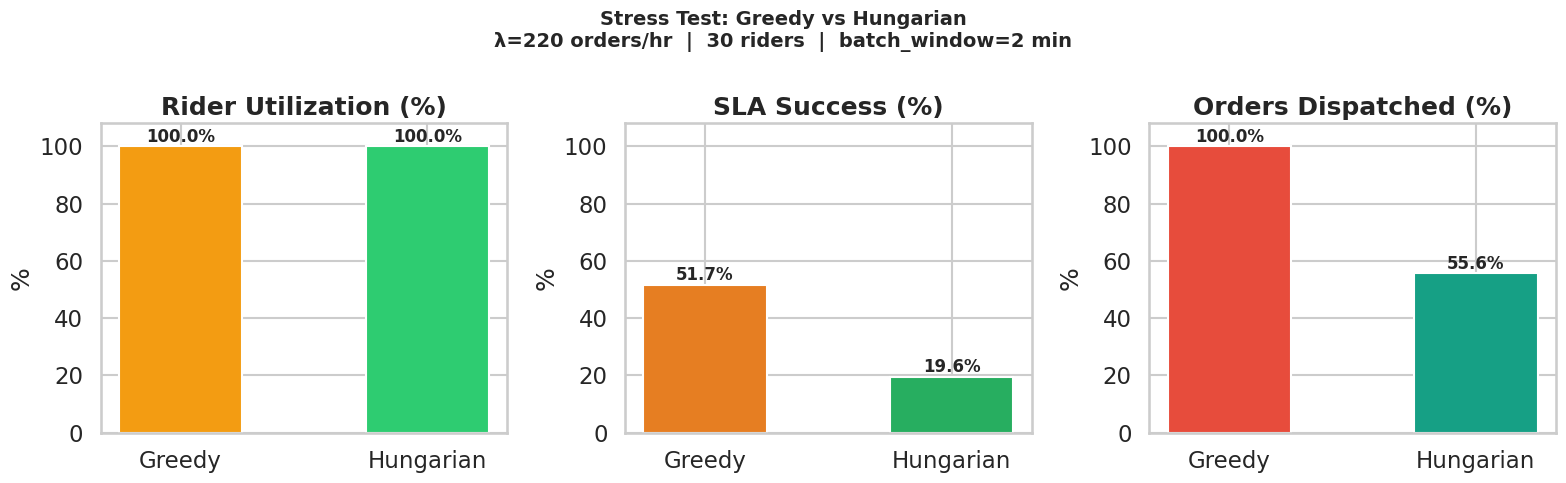

In [15]:
# ══════════════════════════════════════════════════════════════════
# STRESS TEST — Differentiated Utilization: Greedy vs Hungarian
# Parameters: more orders, fewer riders, tighter batch window
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import time
from datetime import datetime, timedelta
from scipy.optimize import linear_sum_assignment

# ── Stressed parameters ───────────────────────────────────────────
STRESS_LAMBDA_PH   = 220   # orders/hour  (was 100  → fleet now overloaded)
STRESS_N_RIDERS    = 30    # riders       (was 60   → half the fleet)
STRESS_BATCH_WINDOW = 2    # minutes      (was 3    → tighter windows = smaller batches)
STRESS_DURATION    = 180   # same 3-hour window

np.random.seed(99)         # different seed → different spatial spread

# ── Re-generate stressed orders ───────────────────────────────────
zones   = list(BENGALURU_DATA.keys())
weights = np.array([BENGALURU_DATA[z][2] for z in zones]); weights /= weights.sum()

stress_orders, t_curr = [], 0.0
while t_curr < STRESS_DURATION:
    t_curr += np.random.exponential(60 / STRESS_LAMBDA_PH)
    if t_curr > STRESS_DURATION: break
    z = np.random.choice(zones, p=weights)
    blat, blon, _ = BENGALURU_DATA[z]
    stress_orders.append({
        "order_id":    len(stress_orders) + 1,
        "zone":        z,
        "dest_lat":    blat + np.random.uniform(-0.01, 0.01),
        "dest_lon":    blon + np.random.uniform(-0.01, 0.01),
        "arrival_time": SIM_START + timedelta(minutes=t_curr),
        "batch_window": int(t_curr // STRESS_BATCH_WINDOW),
    })
stress_orders_df = pd.DataFrame(stress_orders)

# ── Re-generate stressed riders ───────────────────────────────────
stress_riders = []
for i in range(STRESS_N_RIDERS):
    z = np.random.choice(zones)
    login_offset = 0 if np.random.rand() < 0.40 else np.random.uniform(0, 60)
    shift_dur    = np.random.uniform(120, 240)
    login_time   = SIM_START + timedelta(minutes=login_offset)
    stress_riders.append({
        "rider_id":     f"SR-{i+1:03d}",
        "lat":          BENGALURU_DATA[z][0],
        "lon":          BENGALURU_DATA[z][1],
        "capacity":     np.random.choice([2, 3]),
        "available_at": login_time,
        "logout_at":    login_time + timedelta(minutes=shift_dur),
        "total_dist":   0.0,
    })
stress_riders_df = pd.DataFrame(stress_riders)

print(f"{'='*55}")
print(f"STRESS TEST — Setup")
print(f"{'='*55}")
print(f"Orders generated : {len(stress_orders_df)}")
print(f"Riders available : {len(stress_riders_df)}")
print(f"Load ratio       : {len(stress_orders_df)/STRESS_N_RIDERS:.1f} orders/rider")

# ── Run Greedy on stressed data ───────────────────────────────────
# Patch BATCH_WINDOW temporarily so form_batches uses stressed window
_orig_bw = BATCH_WINDOW
import builtins
BATCH_WINDOW = STRESS_BATCH_WINDOW   # module-level constant used by form_batches

stress_greedy_results, stress_greedy_fleet, sg_times, sg_costs = \
    run_greedy_batching(stress_orders_df, stress_riders_df)

BATCH_WINDOW = _orig_bw  # restore

# ── Inline Hungarian on stressed data ────────────────────────────
def run_hungarian_stress(orders, riders, batch_window=STRESS_BATCH_WINDOW):
    fleet, results, h_times, h_costs = riders.copy(), [], [], []
    for window in sorted(orders['batch_window'].unique()):
        w_orders = orders[orders['batch_window'] == window]
        if w_orders.empty: continue
        batch_ready = w_orders['arrival_time'].max()

        # Form batches (same greedy spatial grouping)
        processed, batches = set(), []
        for _, o in w_orders.iterrows():
            if o['order_id'] in processed: continue
            batch = [{'order_id': o['order_id'], 'zone': o['zone'],
                      'dest_lat': o['dest_lat'], 'dest_lon': o['dest_lon'],
                      'arrival_time': o['arrival_time']}]
            processed.add(o['order_id'])
            for _, p in w_orders.iterrows():
                if p['order_id'] in processed or len(batch) >= 3: continue
                if haversine(o['dest_lat'], o['dest_lon'],
                             p['dest_lat'], p['dest_lon']) <= BATCH_RADIUS:
                    batch.append({'order_id': p['order_id'], 'zone': p['zone'],
                                  'dest_lat': p['dest_lat'], 'dest_lon': p['dest_lon'],
                                  'arrival_time': p['arrival_time']})
                    processed.add(p['order_id'])
            batches.append(batch)

        avail = fleet[fleet['available_at'] <= batch_ready]
        if avail.empty: avail = fleet

        n_b     = min(len(batches), len(avail))
        batches = batches[:n_b]
        r_lats  = avail['lat'].to_numpy()[:n_b].reshape(1, -1)
        r_lons  = avail['lon'].to_numpy()[:n_b].reshape(1, -1)
        b_lats  = np.array([BENGALURU_DATA[b[0]['zone']][0] for b in batches]).reshape(-1, 1)
        b_lons  = np.array([BENGALURU_DATA[b[0]['zone']][1] for b in batches]).reshape(-1, 1)

        cost_mat         = vectorized_haversine(b_lats, b_lons, r_lats, r_lons)
        t0               = time.perf_counter()
        row_ind, col_ind = linear_sum_assignment(cost_mat)
        h_times.append(time.perf_counter() - t0)
        h_costs.append(cost_mat[row_ind, col_ind].sum())

        r_indices = avail.index.to_numpy()
        for bi, ri_pos in zip(row_ind, col_ind):
            batch = batches[bi]; r_idx = r_indices[ri_pos]
            pickup_lat, pickup_lon, _ = BENGALURU_DATA[batch[0]['zone']]
            best_route, drop_dist = route_brute_force(pickup_lat, pickup_lon, batch)
            d_pick   = haversine(fleet.at[r_idx,'lat'], fleet.at[r_idx,'lon'],
                                 pickup_lat, pickup_lon)
            trip_km  = d_pick + drop_dist
            travel_m = (trip_km / AVG_SPEED) * 60
            done_t   = batch_ready + timedelta(minutes=travel_m + SERVICE_TIME*len(batch))
            last = best_route[-1]
            fleet.at[r_idx, 'lat']          = last['dest_lat']
            fleet.at[r_idx, 'lon']          = last['dest_lon']
            fleet.at[r_idx, 'available_at'] = done_t
            fleet.at[r_idx, 'total_dist']  += trip_km
            for b in batch:
                dur = (done_t - b['arrival_time']).total_seconds() / 60
                results.append({'order_id': b['order_id'], 'duration': dur,
                                'dist': trip_km/len(batch), 'batch_size': len(batch),
                                'sla_success': dur <= SLA_LIMIT})
    return pd.DataFrame(results), fleet, h_times, h_costs

stress_hungarian_results, stress_hungarian_fleet, sh_times, sh_costs = \
    run_hungarian_stress(stress_orders_df, stress_riders_df)

# ── Comparison ────────────────────────────────────────────────────
sg_util = (stress_greedy_fleet['total_dist']   > 0).mean() * 100
sh_util = (stress_hungarian_fleet['total_dist'] > 0).mean() * 100

sg_sla  = stress_greedy_results['sla_success'].mean()   * 100
sh_sla  = stress_hungarian_results['sla_success'].mean() * 100

sg_filled = len(stress_greedy_results)   / len(stress_orders_df) * 100
sh_filled = len(stress_hungarian_results)/ len(stress_orders_df) * 100

print(f"\n{'='*62}")
print(f"STRESS TEST RESULTS  |  λ={STRESS_LAMBDA_PH}/hr  |  {STRESS_N_RIDERS} riders")
print(f"{'='*62}")
print(f"{'Metric':<30} {'Greedy':>14} {'Hungarian':>14}")
print(f"{'-'*62}")
print(f"{'Rider Utilization (%)':<30} {sg_util:>13.1f}% {sh_util:>13.1f}%")
print(f"{'Orders Dispatched (%)':<30} {sg_filled:>13.1f}% {sh_filled:>13.1f}%")
print(f"{'SLA Success (%)':<30} {sg_sla:>13.1f}% {sh_sla:>13.1f}%")
print(f"{'Avg Delivery (min)':<30} {stress_greedy_results['duration'].mean():>14.2f} {stress_hungarian_results['duration'].mean():>14.2f}")
print(f"{'Total Distance (km)':<30} {stress_greedy_fleet['total_dist'].sum():>14.1f} {stress_hungarian_fleet['total_dist'].sum():>14.1f}")
print(f"{'Avg Assignment Cost/cycle':<30} {np.mean(sg_costs):>14.2f} {np.mean(sh_costs):>14.2f}")
print(f"\n→ Utilization gap (Hungarian − Greedy): {sh_util - sg_util:+.1f} pp")
print(f"→ SLA gap         (Hungarian − Greedy): {sh_sla  - sg_sla:+.1f} pp")

# ── Bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Stress Test: Greedy vs Hungarian\n'
             f'λ={STRESS_LAMBDA_PH} orders/hr  |  {STRESS_N_RIDERS} riders  |  '
             f'batch_window={STRESS_BATCH_WINDOW} min',
             fontsize=14, fontweight='bold')

metrics = ['Rider Utilization (%)', 'SLA Success (%)', 'Orders Dispatched (%)']
g_vals  = [sg_util, sg_sla, sg_filled]
h_vals  = [sh_util, sh_sla, sh_filled]
colors  = [('#f39c12', '#2ecc71'), ('#e67e22', '#27ae60'), ('#e74c3c', '#16a085')]

for ax, metric, gv, hv, (gc, hc) in zip(axes, metrics, g_vals, h_vals, colors):
    bars = ax.bar(['Greedy', 'Hungarian'], [gv, hv], color=[gc, hc],
                  edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 108)
    ax.set_ylabel('%')
    for bar, v in zip(bars, [gv, hv]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1.5,
                f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()

print("\nStress test chart saved!")
plt.show()